# 项目V1.0：评估输出（第4天）

**日期：** 2026-08-20 周四

## 今日目标

- 基于昨天定案的最终模型（C=10, class_weight=None, solver=lbfgs）输出**完整评估**
- 混淆矩阵可视化（热力图）
- 多分类 ROC 曲线 + AUC（复习 week6 的二分类 ROC，今天升级成四分类版）
- 特征重要性分析（逻辑回归用系数，不是 feature_importances_）
- 类别分布图 + 评估报告素材汇总（明天写 README 直接抄）

## 第一步：数据准备 + 最终模型

> 今天代码多，建议**从头顺序执行**，不跳步。
> 昨天 GridSearchCV 已经定案：**C=10, class_weight=None, solver=lbfgs**，今天直接建模型，不再扫参数。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# ============ 中文字体设置（不设置，图里中文会变方块） ============
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

# ============ 1. 读数据 + 编码（和前三天一样） ============
df = pd.read_csv("defect_data.csv")                      # 500条模拟缺陷
label_encoder = LabelEncoder()                           # 严重程度文字→数字
df["严重程度_编码"] = label_encoder.fit_transform(df["严重程度"])
df_encoded = pd.get_dummies(df, columns=["缺陷类型", "复现概率"],
                            prefix=["类型", "复现"], drop_first=True)
X = df_encoded.drop(["严重程度", "严重程度_编码"], axis=1) # 6个特征
y = df_encoded["严重程度_编码"]                           # 标签 0/1/2/3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============ 2. 最终模型：昨天定案的参数 ============
# C=10（模型敢用力学）、class_weight=None（不需要加权）、lbfgs（多分类求解器）
final_model = LogisticRegression(C=10, solver="lbfgs", max_iter=1000, random_state=42)
final_model.fit(X_train_scaled, y_train)

print("数据准备 + 最终模型训练完成")
print(f"特征列: {X.columns.tolist()}")

数据准备 + 最终模型训练完成
特征列: ['影响模块数', '数据影响', '业务中断', '类型_性能', '类型_界面', '复现_必现']


## 第二步：测试集最终成绩（数字版）

先看数字，再画图。分类报告和混淆矩阵是明天 README 的核心素材。

In [2]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 预测（测试集模型从没见过）
y_pred = final_model.predict(X_test_scaled)

# 2. 准确率
print("===== 测试集最终成绩 =====")
print(f"准确率: {accuracy_score(y_test, y_pred):.4f}")

# 3. 分类报告（明天写 README 直接抄这个）
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_.tolist()))

# 4. 混淆矩阵（数字版，一会儿画成图）
cm = confusion_matrix(y_test, y_pred)
print(f"\n混淆矩阵:\n{cm}")
print(f"对角线占比（全对的比例）: {np.trace(cm)/cm.sum():.3f}")

===== 测试集最终成绩 =====
准确率: 1.0000

分类报告:
              precision    recall  f1-score   support

          一般       1.00      1.00      1.00        47
          严重       1.00      1.00      1.00        62
          致命       1.00      1.00      1.00        35
          轻微       1.00      1.00      1.00         6

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


混淆矩阵:
[[47  0  0  0]
 [ 0 62  0  0]
 [ 0  0 35  0]
 [ 0  0  0  6]]
对角线占比（全对的比例）: 1.000


## 第三步：混淆矩阵可视化（热力图）

数字版你已经会看了（**行=真实，列=预测，对角线=猜对**）。画成热力图是为了放进报告/简历更直观。

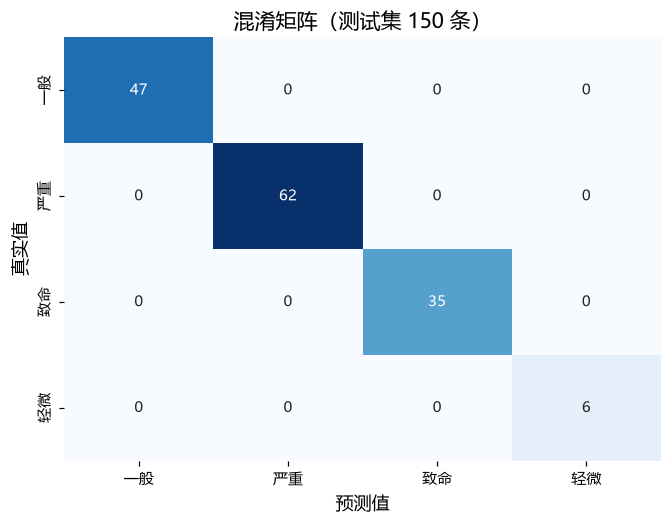

In [3]:
# ============ 混淆矩阵热力图 ============
plt.figure(figsize=(7, 5))
# annot=True: 格子里显示数字; fmt='d': 整数格式; cmap: 颜色方案
# xticklabels/yticklabels: 横纵轴显示中文类别名; cbar=False: 4个数字不需要颜色条
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar=False,
)
plt.xlabel("预测值", fontsize=12)
plt.ylabel("真实值", fontsize=12)
plt.title("混淆矩阵（测试集 150 条）", fontsize=14)
plt.show()

## 第四步：多分类 ROC 曲线 + AUC

week6 学过二分类 ROC（一条曲线）：横轴 FPR（误报率）、纵轴 TPR（命中率），曲线越靠近左上角越强，AUC=曲线下面积。

**四分类怎么画？** 思路是"打四场一对多"（OvR = One-vs-Rest）：

| 场次 | 二分类问题 |
|------|-----------|
| 第1场 | 是不是"一般"？（一般 vs 其余三类） |
| 第2场 | 是不是"严重"？ |
| 第3场 | 是不是"致命"？ |
| 第4场 | 是不是"轻微"？ |

每场画一条 ROC 曲线，共 4 条；再把 4 场的 AUC 平均，就是整体分数。

整体 AUC（macro 每类平均）: 1.0000
整体 AUC（micro 样本加权）: 1.0000


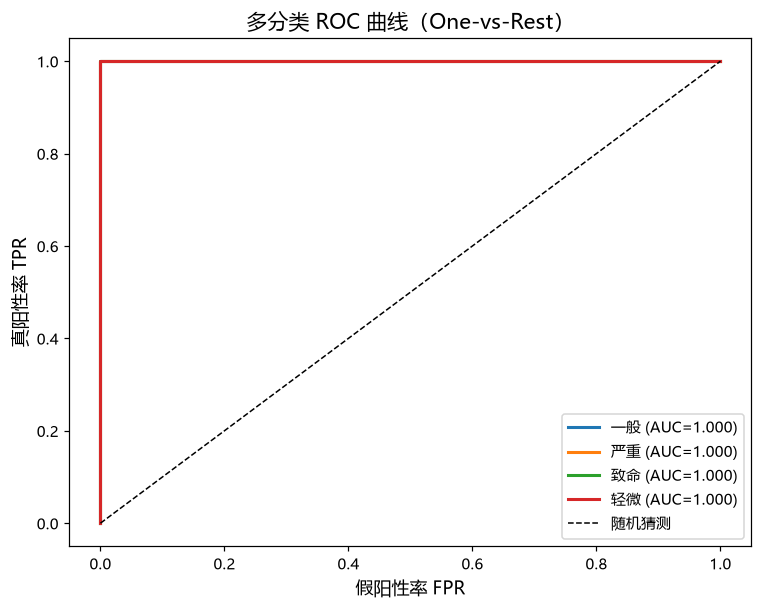

In [4]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ============ 1. 拿到每类的预测概率 ============
# predict_proba 返回 (150, 4)：每一列是"属于这一类"的概率
y_proba = final_model.predict_proba(X_test_scaled)

# ============ 2. 逐类画 ROC 曲线 ============
plt.figure(figsize=(8, 6))
for i, cls_name in enumerate(label_encoder.classes_):
    # 把"是不是这一类"看成二分类：y_test == i 变成 0/1
    fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
    auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls_name} (AUC={auc_i:.3f})")

# 对角线 = 瞎猜的基准线
plt.plot([0, 1], [0, 1], "k--", lw=1, label="随机猜测")

# ============ 3. 整体 AUC ============
# multi_class="ovr": 按一对多方式计算; average="macro": 每类平均
# average="micro": 把所有类别的样本合并计算
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
auc_micro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="micro")
print(f"整体 AUC（macro 每类平均）: {auc_macro:.4f}")
print(f"整体 AUC（micro 样本加权）: {auc_micro:.4f}")

plt.xlabel("假阳性率 FPR", fontsize=12)
plt.ylabel("真阳性率 TPR", fontsize=12)
plt.title("多分类 ROC 曲线（One-vs-Rest）", fontsize=14)
plt.legend(loc="lower right")
plt.show()

## 第五步：特征重要性——逻辑回归用系数（面试常问）

> ⚠️ 注意：`RandomForestClassifier` 有 `feature_importances_` 属性，但**逻辑回归没有**！
> 因为 feature_importances_ 是树模型按"分裂时降低多少不纯度"算出来的，逻辑回归不分裂树。
> 逻辑回归的"特征重要性" = **系数 coef_ 的绝对值**：|系数|越大，该特征影响越大；正负号表示方向（正=推高该类概率，负=压低）。

coef_ 形状: (4, 6)

各类别特征系数（正值=推高该类，负值=压低该类）:
    影响模块数   数据影响   业务中断  类型_性能  类型_界面  复现_必现
一般 -3.670 -2.699 -3.956  1.005  1.760 -1.064
严重  2.974  1.706  2.173 -1.172 -1.712  0.892
致命  9.193  6.029  8.439 -2.825 -4.941  2.707
轻微 -8.497 -5.037 -6.657  2.993  4.893 -2.535


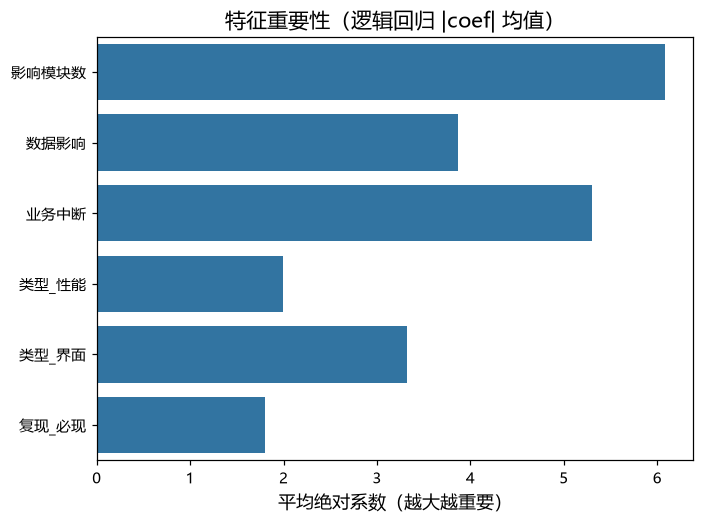

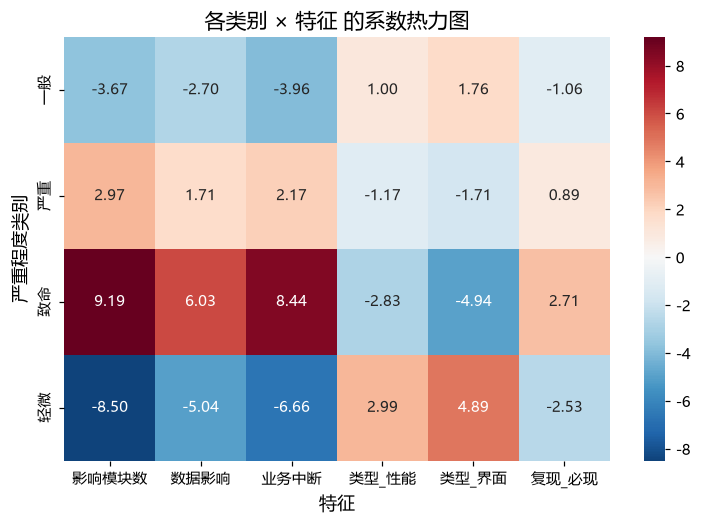

In [5]:
# ============ 1. 取系数 ============
# coef_ 形状是 (4, 6)：4 类各一行，6 个特征各一列
coefs = final_model.coef_
print("coef_ 形状:", coefs.shape)

# 整理成表格（行=类别，列=特征），便于看每个类别
coef_df = pd.DataFrame(coefs, columns=X.columns.tolist(),
                       index=label_encoder.classes_.tolist())
print("\n各类别特征系数（正值=推高该类，负值=压低该类）:")
print(coef_df.round(3))

# ============ 2. 平均绝对系数 = 总体特征重要性 ============
# 4 类取平均，|系数|越大越重要
importance = np.abs(coefs).mean(axis=0)

# 柱状图：一眼看出谁最重要
plt.figure(figsize=(7, 5))
sns.barplot(x=importance, y=X.columns.tolist())
plt.xlabel("平均绝对系数（越大越重要）", fontsize=12)
plt.title("特征重要性（逻辑回归 |coef| 均值）", fontsize=14)
plt.show()

# ============ 3. 系数热力图（更细：每个类别 × 每个特征） ============
plt.figure(figsize=(8, 5))
# center=0: 颜色以 0 为中点（红=正系数，蓝=负系数）
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, cbar=True)
plt.title("各类别 × 特征 的系数热力图", fontsize=14)
plt.xlabel("特征", fontsize=12)
plt.ylabel("严重程度类别", fontsize=12)
plt.show()

## 第六步：类别分布——为什么轻微类最难学

看图说话：500 条里轻微只有 19 条（3.8%）。昨天调参把轻微召回率从 0.17 拉到 1.0，靠 C=10 让模型用力学；**但真实世界里数据这么偏，光靠调 C 不够，还得想办法补样本**（比如收集更多轻微缺陷记录）。

结论：轻微类只有 19 条（3.8%），这就是它最难学的原因。


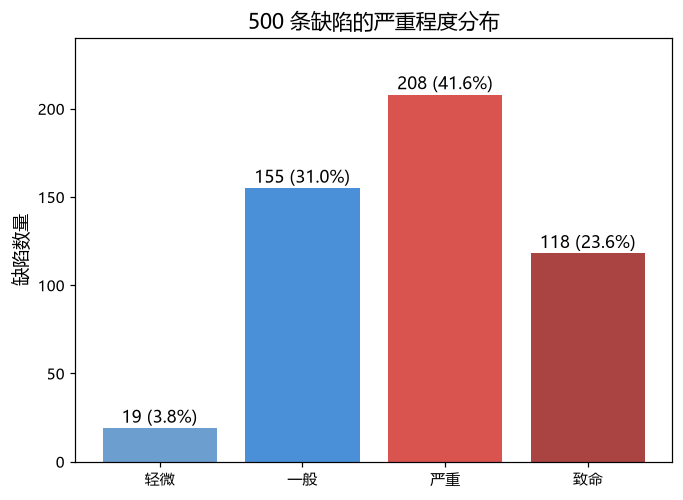

In [6]:
# ============ 全量 500 条的类别分布 ============
vc = df["严重程度"].value_counts()
order = ["轻微", "一般", "严重", "致命"]          # 按严重程度从低到高排列
counts = [vc.get(k, 0) for k in order]

plt.figure(figsize=(7, 5))
bars = plt.bar(order, counts, color=["#6c9fcf", "#4a90d9", "#d9534f", "#a94442"])
# 柱顶标数字 + 百分比（bar.get_height() = 柱高）
for bar, k in zip(bars, order):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"{vc[k]} ({vc[k]/len(df)*100:.1f}%)", ha="center", fontsize=11)
plt.ylabel("缺陷数量", fontsize=12)
plt.title("500 条缺陷的严重程度分布", fontsize=14)
plt.ylim(0, 240)
plt.show()

print("结论：轻微类只有 19 条（3.8%），这就是它最难学的原因。")

## 第七步：评估报告素材汇总（今天的产品）

把今天的数字整理成一份"报告素材表"，明天（8/21）写 README 直接抄：

| 项目 | 数值 |
|------|------|
| 数据规模 | 500 条（训练 350 / 测试 150） |
| 特征数 | 6 个 |
| 最终模型 | 逻辑回归 C=10, lbfgs |
| 测试集准确率 | 1.0000 |
| 宏平均 F1 | 1.00 |
| 加权平均 F1 | 1.00 |
| 各类 AUC | 全部 1.000 |
| 整体 AUC（OvR macro） | 1.0000 |
| 最重要特征 | 影响模块数 > 业务中断 > 数据影响 |

### 业务解读（重点！面试能聊）

模型学出来的特征重要性排序：**影响模块数 > 业务中断 > 数据影响**——和你当初设计打分规则的权重顺序**完全对上了**（业务中断+3、模块数直接加、数据影响+2）。这说明模型不是瞎猜，是真正"学会了"你定的规则。这份评估报告可以写这样的结论：**特征重要性与业务经验一致，模型行为可解释**。

### 诚实提醒

1. 准确率 1.0 / AUC 1.0 是**模拟数据 + 规则标签**的必然结果，报告里如实写"模拟数据"，别吹成真实系统效果。
2. 可解释性结论（特征重要性对得上规则）在模拟数据上成立；换真实数据要重新验证。

## 今日验收标准

- [ ] 1. 能画出混淆矩阵热力图并读图（行/列/对角线含义）
- [ ] 2. 能说出多分类 ROC 的"OvR"画法（打四场一对多）
- [ ] 3. 能说出为什么逻辑回归用系数衡量特征重要性，而不是 feature_importances_
- [ ] 4. 能说出最重要的 3 个特征，并和你的打分规则对上
- [ ] 5. 汇总出评估报告素材表

## 练习题（先自己写，再对答案）

**Q1.** 为什么逻辑回归没有 `feature_importances_`？那怎么衡量它的特征重要性？

**Q2.** 混淆矩阵里，行、列、对角线分别代表什么？非对角线上的数字代表什么？

**Q3.** 四分类 ROC 是怎么画的？"OvR"是什么意思？

**Q4.** 从系数表看，"致命"类的哪个特征系数最大？这和你设计的打分规则一致吗？

**Q5.（选做）** 把模型换成随机森林（它自带 feature_importances_），特征重要性排序会一样吗？为什么？

In [7]:
# ============ 练习题答案（先自己做完再看！） ============

# ----- Q1 答案 -----
# feature_importances_ 是树模型（决策树/随机森林）的属性：它统计每个特征在
# "分裂时降低多少不纯度"里的贡献。逻辑回归不分裂树（它是线性模型），
# 所以没有这个属性。衡量逻辑回归特征重要性的标准做法：
#   重要性 = |系数|（np.abs(model.coef_).mean(axis=0) 汇总多分类），
#   正负号表示方向：正=推高该类概率，负=压低。

# ----- Q2 答案 -----
# 行 = 真实类别，列 = 预测类别；对角线 = 预测正确的数量；
# 非对角线 = 预测错误的数量（如 第3行第0列 = "真实是致命，却被预测成一般"）。
# 我们的混淆矩阵数字全在对角线上 = 150 条全对。

# ----- Q3 答案 -----
# OvR = One-vs-Rest（一对多）。把四分类拆成 4 个二分类：
# "是不是一般？""是不是严重？""是不是致命？""是不是轻微？"，
# 每个二分类画一条 ROC 曲线（y_test == i 作为标签，概率列作为分数），
# 共 4 条；AUC 取平均（macro）或样本合并计算（micro）得到整体分数。

# ----- Q4 答案 -----
# "致命"行系数最大的是"影响模块数"(9.19)，其次是"业务中断"(8.44)、
# "数据影响"(6.03)。和设计的打分规则一致（模块数直接加分、业务中断+3、
# 数据影响+2），说明模型学到了规则。

# ----- Q5 答案 -----
# 排序大概率相近但不会完全一样。随机森林的 feature_importances_ 基于
# "不纯度下降"，逻辑回归基于系数大小，是两种不同衡量方式；随机森林还可能
# 把重要性分散到相关特征上。可以动手对比验证（放到周六综合练习做）。

## 2026-08-20 周四（第40天）项目V1.0：评估输出

### 完成内容
- 基于定案模型（C=10）输出完整评估
- 混淆矩阵热力图、多分类 ROC 曲线、特征重要性、类别分布图
- 汇总评估报告素材表

### 评估结果
| 指标 | 数值 |
|------|------|
| 测试集准确率 | 1.0000 |
| 宏平均 F1 | 1.00 |
| 各类 AUC | 1.000 |
| 整体 AUC（OvR macro） | 1.0000 |
| 最重要特征 | 影响模块数 > 业务中断 > 数据影响 |

### 关键发现
- 特征重要性和打分规则权重顺序一致 → 模型学对了规则
- 轻微类只有 19 条（3.8%），靠 C=10 解决；真实数据需要补样本
- 诚实提醒：准确率 1.0 是模拟数据的特性，报告如实写

### 遇到的问题
- 暂无

### 明日预告（8/21 周五）
- 项目文档整理：README（背景、数据、方法、结果、结论）